In [146]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv("GlobalTemperatures.csv")
df

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
3187,2015-08-01,14.755,0.072,20.699,0.110,9.005,0.170,17.589,0.057
3188,2015-09-01,12.999,0.079,18.845,0.088,7.199,0.229,17.049,0.058
3189,2015-10-01,10.801,0.102,16.450,0.059,5.232,0.115,16.290,0.062
3190,2015-11-01,7.433,0.119,12.892,0.093,2.157,0.106,15.252,0.063


In [147]:
#Extracting year from the date attribute

df['dt'] = pd.to_datetime(df['dt'])
df['Year'] = df['dt'].dt.year
df['Mois'] = df['dt'].dt.month

In [148]:
# Group
annual_df = df.groupby('Year')['LandAverageTemperature'].mean().reset_index()
# Missing values
annual_df = annual_df.dropna()

print(annual_df)

     Year  LandAverageTemperature
0    1750                8.719364
1    1751                7.976143
2    1752                5.779833
3    1753                8.388083
4    1754                8.469333
..    ...                     ...
261  2011                9.516000
262  2012                9.507333
263  2013                9.606500
264  2014                9.570667
265  2015                9.831000

[266 rows x 2 columns]


C:\Users\lilia\AppData\Local\Temp\ipykernel_18728\1360054919.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


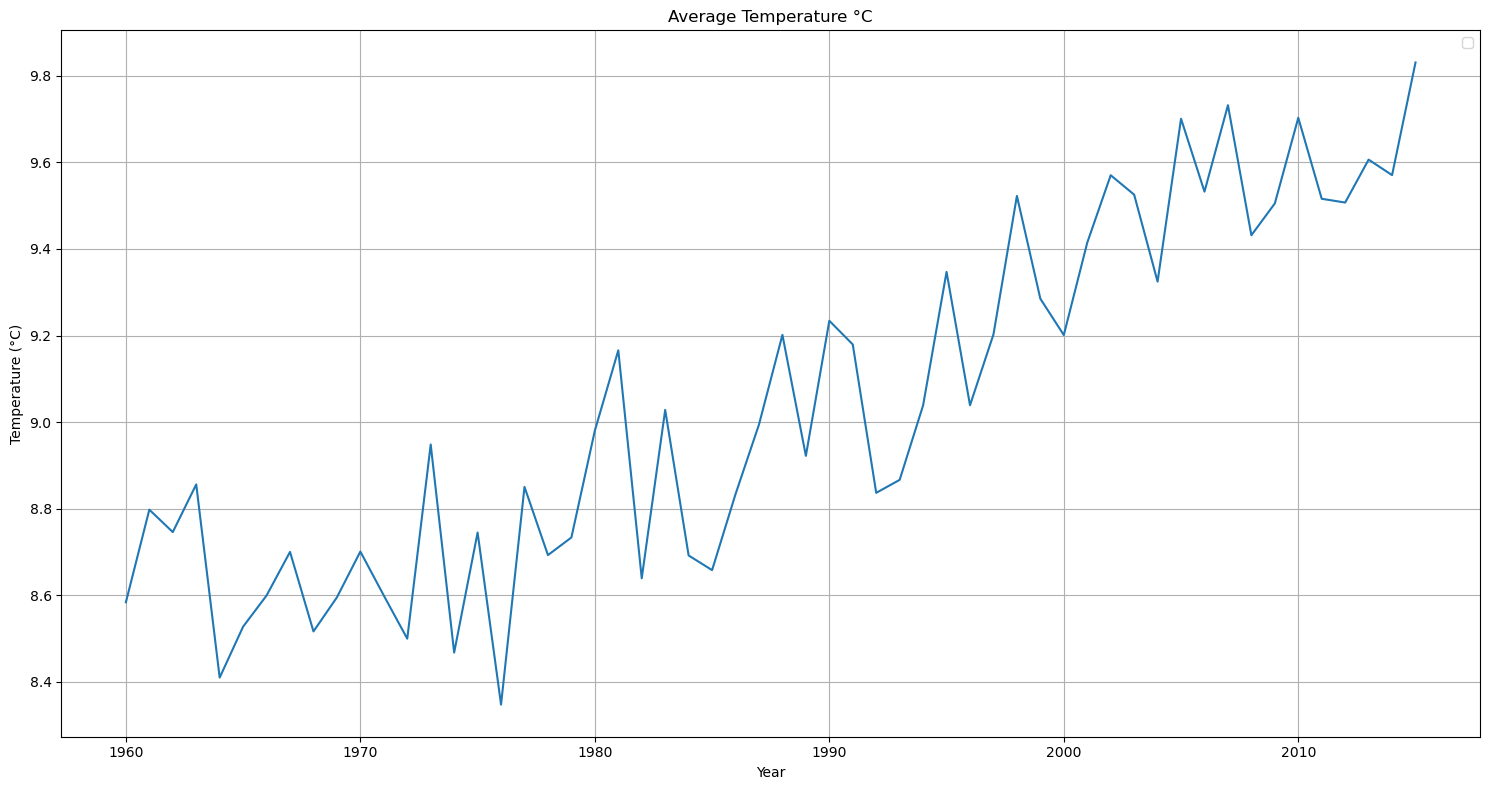

In [156]:
# Filter from ... (you can change this year)
annual_df = annual_df[annual_df['Year'] >= 1960]


plt.figure(figsize=(15, 8))
sns.lineplot(x="Year", y="LandAverageTemperature", data=annual_df) 
plt.title(f'Average Temperature °C')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [157]:
#  Perform linear regression by season
for Temp in annual_df['Year'].unique():
    X = annual_df[['Year']]
    y = annual_df['LandAverageTemperature']
    
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

In [158]:
# Sort for clean plotting
sorted_idx = X['Year'].argsort()
X_sorted = X.iloc[sorted_idx]
y_pred_sorted = y_pred[sorted_idx]

Slope (coefficient): 0.022182456140350883


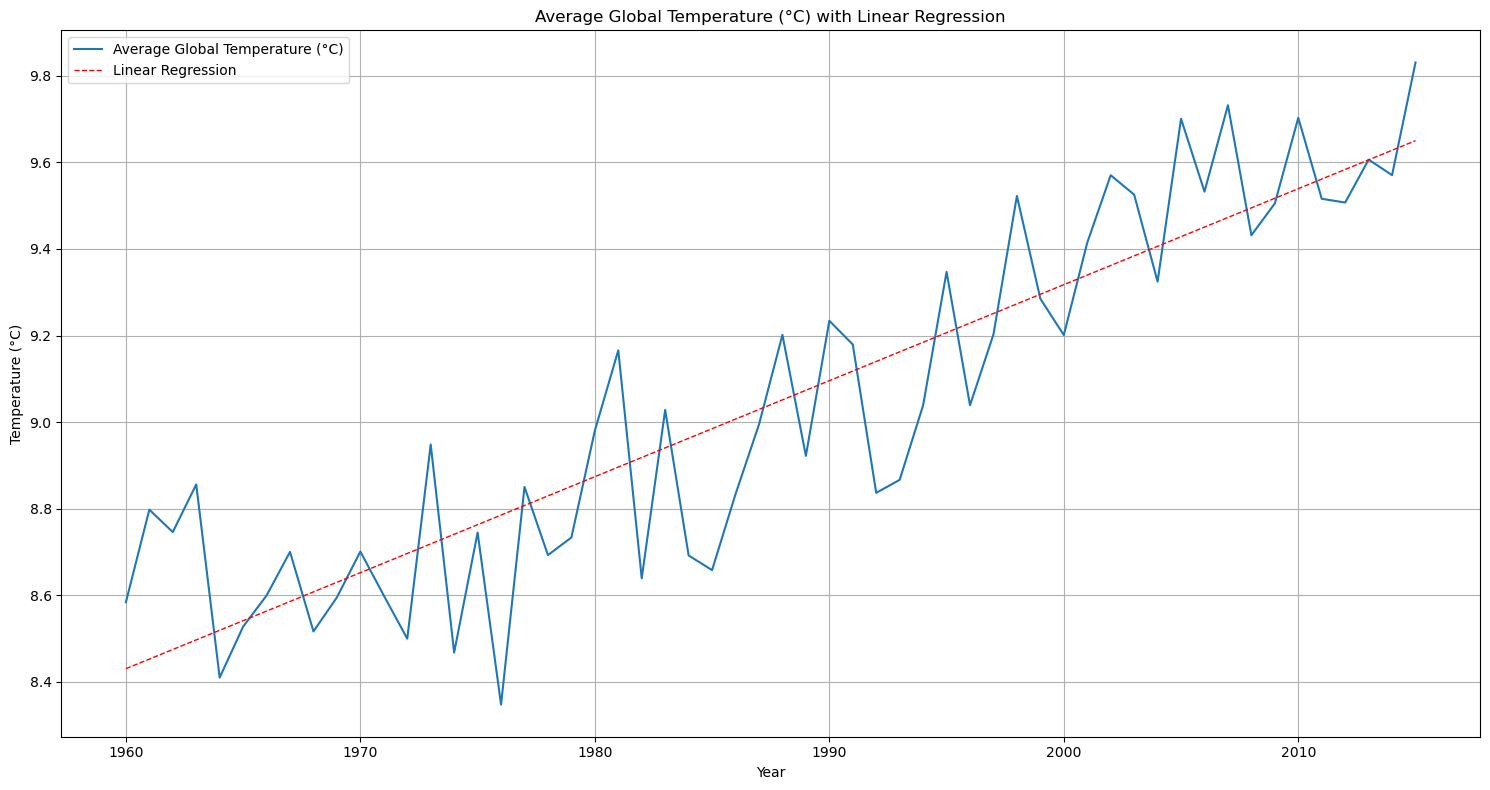

In [159]:
plt.figure(figsize=(15, 8))
sns.lineplot(x="Year", y="LandAverageTemperature", data=annual_df, label="Average Global Temperature (°C)" )
plt.plot(X_sorted, y_pred_sorted, color='red', linestyle='--', linewidth=1, label='Linear Regression')

# Labels and styling
plt.title('Average Global Temperature (°C) with Linear Regression')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
print(f"Slope (coefficient): {model.coef_[0]}")
plt.show()